# Importacion de librerias

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Exploracion y entendimiento del dataset

Es un dataset sobre los niveles de obesidad en mexico, colombia y peru basado en sus habitos alimenticios y en su condicion fisica

In [62]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [63]:
df['FAVC'].value_counts()

FAVC
yes    1866
no      245
Name: count, dtype: int64

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

Variable,Tipo,Descripción

Gender-->Categórica,Género de la persona (Female / Male)

Age-->Continua,Edad en años

Height-->Continua,Altura en metros

Weight-->Continua,Peso en kilogramos

family_history_with_overweight-->Binaria,¿Tiene antecedentes familiares de sobrepeso? (yes / no)

FAVC-->Binaria,¿Consume frecuentemente alimentos altos en calorías? (yes / no)

FCVC-->Entero (Ordinal),"Frecuencia de consumo de vegetales en las comidas (1 = Nunca, 2 = A veces, 3 = Siempre)"

NCP-->Continua,Número de comidas principales al día

CAEC-->Categórica,Consumo de comida entre comidas (no / Sometimes / Frequently / Always)

SMOKE-->Binaria,¿Fuma? (yes / no)

CH2O-->Continua,Cantidad de agua consumida diariamente (en litros aproximados)

SCC-->Binaria,¿Monitorea las calorías que consume? (yes / no)

FAF-->Continua,"Frecuencia de actividad física (0 = Ninguna, 3 = Muy frecuente)"

TUE-->Continua,Tiempo de uso de dispositivos tecnológicos al día (en horas)

CALC-->Categórica,Frecuencia de consumo de alcohol (no / Sometimes / Frequently / Always)

MTRANS-->Categórica,"Medio de transporte habitual (Public_Transportation, Automobile, Walking, Motorbike, Bike)"

NObeyesdad-->Categórica (Target),"Nivel de obesidad (Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III)"

In [65]:
df['CH2O'].value_counts()

CH2O
2.000000    448
1.000000    211
3.000000    162
2.825629      3
1.636326      3
           ... 
1.728139      1
2.005130      1
2.054193      1
2.852339      1
2.863513      1
Name: count, Length: 1268, dtype: int64

# Transformacion de Categoricos a numericos

Para transformar de categoricos a numericos vamos a usar ordinals y one hot.

Gender--> Binaria

family_history_with_overweight-->Binaria

FAVC--> binaria

CAEC-->ordinal

smoke-->binaria

SCC	--> binaria

CALC--> ordinal

MTRANS--> one hot

NObeyesdad--> ordinal


## Ordinal

In [66]:
df['CALC'].value_counts()

CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

In [67]:
df['CAEC'].value_counts()

CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

In [68]:
#columnas que vamos a aplicar ordinal
colums = ['CAEC','CALC']

# Se asigna en orden los valores que va a tener al aplicar el metodo ordinal (0,1,2,3)
categories_ordinal=[['no','Sometimes','Frequently','Always'],# orden para CAEC
                    ['no','Sometimes','Frequently','Always']]#ORden para CALC

In [69]:
# asignacion de valores ordinal
encoded_ord = OrdinalEncoder(categories=categories_ordinal) # se crea el objeto para aplicar el fit_transform, con las categorias creadas

df_encoded = encoded_ord.fit_transform(df[colums])# se hace el ordinal

df[colums] = df_encoded # se asignan esos resultados al dataframe original
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,1.0,no,2.0,no,0.0,1.0,0.0,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.0,yes,3.0,yes,3.0,0.0,1.0,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,1.0,no,2.0,no,2.0,1.0,2.0,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,1.0,no,2.0,no,2.0,0.0,2.0,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,1.0,no,2.0,no,0.0,0.0,1.0,Public_Transportation,Overweight_Level_II


quedo de la siguiente forma para las dos columnas(['CAEC','CALC'])

no---> 0

Sometimes---> 1

Frequently---> 2

Always---> 3

In [70]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [71]:
print(df['NObeyesdad'].unique())

<StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str


In [72]:
# Mapeamos las categorias que se van converitr en numericas
categories_ordinal_NObesyesdad = [['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']] # para que funcione necesita pasarle una lista de listas
column_or=['NObeyesdad']

In [73]:
encoded_ord_obeyesdad = OrdinalEncoder(categories=categories_ordinal_NObesyesdad)
df_encoded_ = encoded_ord_obeyesdad.fit_transform(df[column_or])
df[column_or] =df_encoded_ 
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,1.0,no,2.0,no,0.0,1.0,0.0,Public_Transportation,1.0
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.0,yes,3.0,yes,3.0,0.0,1.0,Public_Transportation,1.0
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,1.0,no,2.0,no,2.0,1.0,2.0,Public_Transportation,1.0
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,1.0,no,2.0,no,2.0,0.0,2.0,Walking,2.0
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,1.0,no,2.0,no,0.0,0.0,1.0,Public_Transportation,3.0


Quedo de la siguiente forma

Insufficient_Weight--> 0

Normal_Weight--> 1

Overweight_Level_I--> 2

Overweight_Level_II--> 3

Obesity_Type_I--> 4

Obesity_Type_II--> 5

Obesity_Type_III--> 6

## One Hot

In [74]:
encoder_one = OneHotEncoder(sparse_output=False) # inicializamos el objeto

df_one =encoder_one.fit_transform(df[['MTRANS']])
print(df_one)

[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]]


In [75]:
print(encoder_one.get_feature_names_out())
columns_one = encoder_one.get_feature_names_out() # Para llamar las columnas en el orden que establecio one hot que es alfabetico

['MTRANS_Automobile' 'MTRANS_Bike' 'MTRANS_Motorbike'
 'MTRANS_Public_Transportation' 'MTRANS_Walking']


In [76]:
# ahora lo convertimos a un dataFrame
df_one = pd.DataFrame(df_one, 
                      columns = columns_one, 
                      index=df.index)

# lo concatenamos al df original
df = pd.concat([df.drop(columns=['MTRANS']),df_one],axis = 1)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,1.0,no,...,no,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.0,yes,...,yes,3.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,1.0,no,...,no,2.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,1.0,no,...,no,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,1.0,no,...,no,0.0,0.0,1.0,3.0,0.0,0.0,0.0,1.0,0.0


# Estandarizacion de variables

Age-->Continua,Edad en años

Height-->Continua,Altura en metros

Weight-->Continua,Peso en 

NCP-->Continua,Número de comidas principales al día

CH2O-->Continua,Cantidad de agua consumida diariamente (en litros aproximados)

FAF-->Continua,"Frecuencia de actividad física (0 = Ninguna, 3 = Muy frecuente)"

TUE-->Continua,Tiempo de uso de dispositivos tecnológicos al día (en horas)


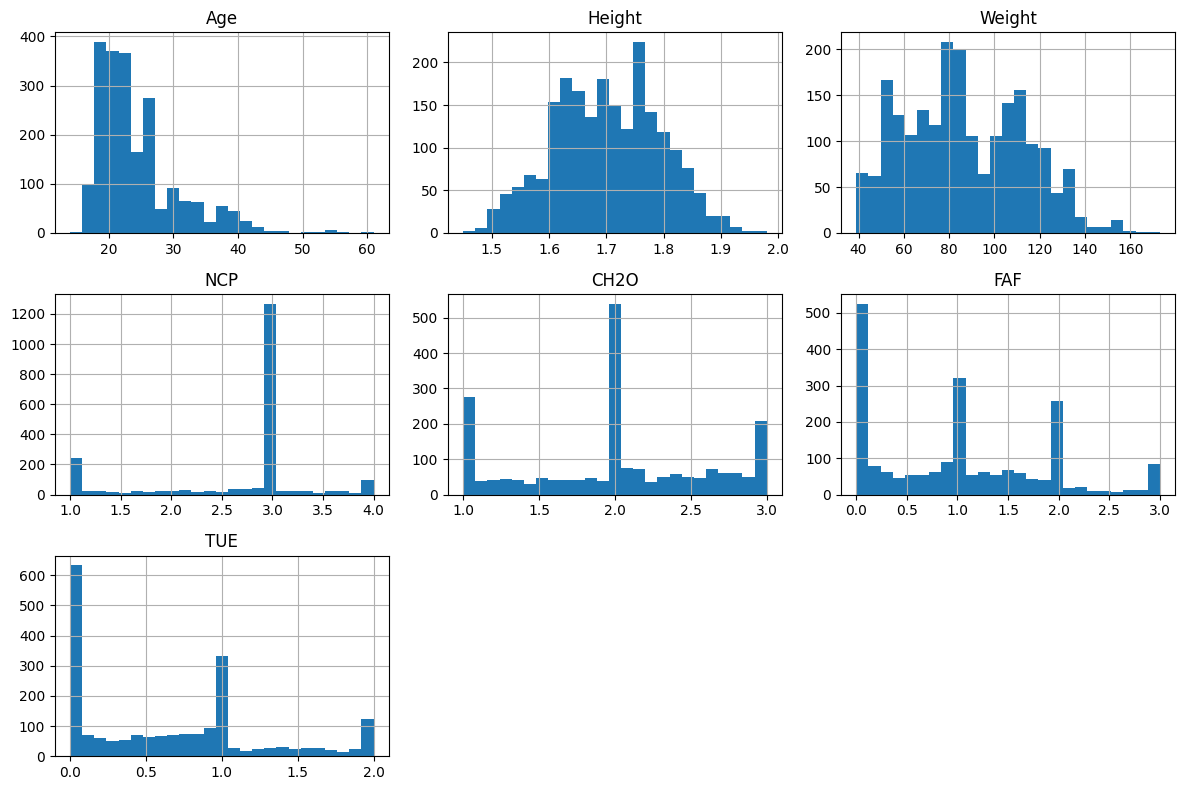

In [77]:
columnas_std = ['Age', 'Height','Weight', 'NCP', 'CH2O', 'FAF', 'TUE']

df[columnas_std].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

In [78]:
scaler = StandardScaler()
df_std = scaler.fit_transform(df[columnas_std])
df[columnas_std] = df_std
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Female,-0.522124,-0.875589,-0.862558,yes,no,2.0,0.404153,1.0,no,...,no,-1.188039,0.561997,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,Female,-0.522124,-1.947599,-1.168077,yes,no,3.0,0.404153,1.0,yes,...,yes,2.339750,-1.080625,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Male,-0.206889,1.054029,-0.366090,yes,no,2.0,0.404153,1.0,no,...,no,1.163820,0.561997,2.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Male,0.423582,1.054029,0.015808,no,no,3.0,0.404153,1.0,no,...,no,1.163820,-1.080625,2.0,2.0,0.0,0.0,0.0,0.0,1.0
4,Male,-0.364507,0.839627,0.122740,no,no,2.0,-2.167023,1.0,no,...,no,-1.188039,-1.080625,1.0,3.0,0.0,0.0,0.0,1.0,0.0


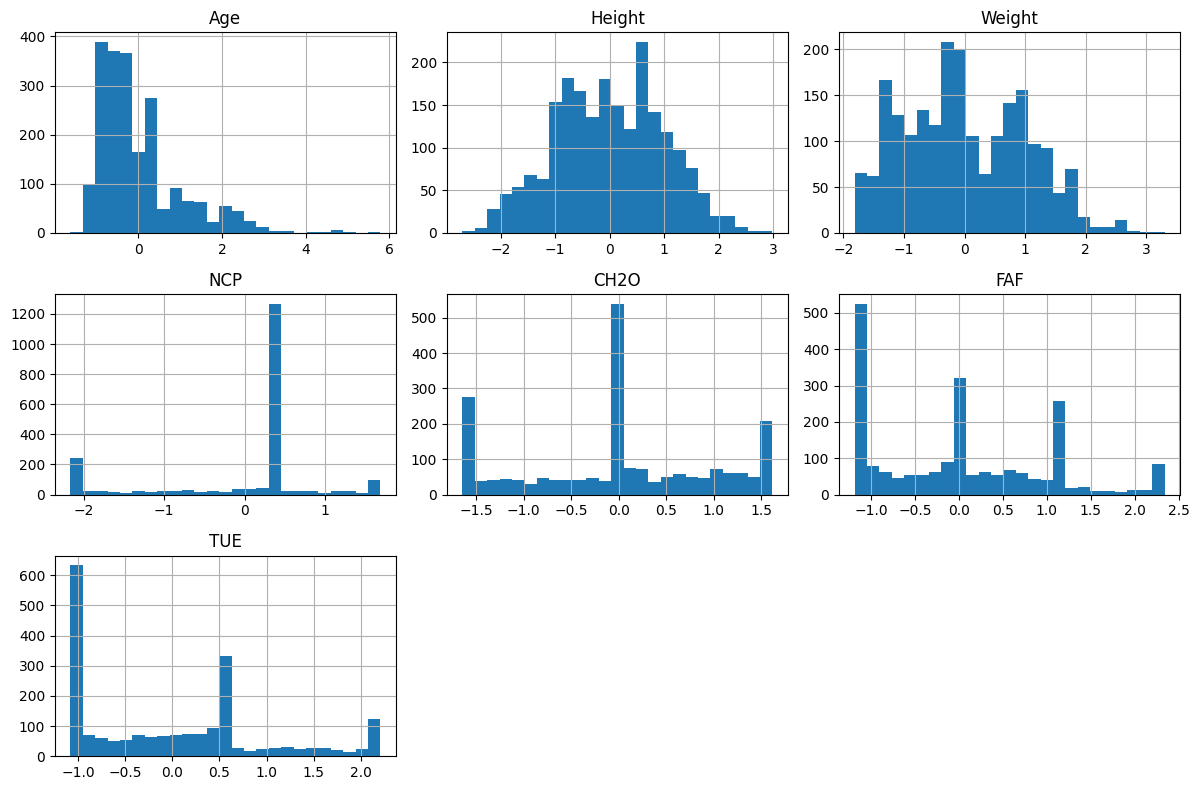

In [79]:
df[columnas_std].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

# Preguntas


## 1. Si la perssona tiene historial de sobre peso en su familia es mas proable que presente cualquier tipo de obesidad?

Posibles preguntas

Exploratorias

¿Cuál es la distribución de los niveles de obesidad en el dataset?

¿Qué porcentaje de la muestra corresponde a cada género?

¿Cuál es la edad promedio de las personas con obesidad tipo III?

¿Cuántas personas tienen antecedentes familiares de sobrepeso?


De correlación

¿Existe relación entre la frecuencia de actividad física (FAF) y el nivel de obesidad?

¿Los personas que consumen comida calórica frecuentemente (FAVC) tienen mayor peso?

¿A mayor consumo de agua (CH2O) menor nivel de obesidad?

¿El tiempo de uso de tecnología (TUE) se relaciona con menor actividad física?

¿Existe diferencia en el IMC entre hombres y mujeres?


Predictivas

¿Qué variables son las más determinantes para predecir el nivel de obesidad?

¿El consumo de vegetales (FCVC) reduce la probabilidad de obesidad?

¿Las personas que monitorean sus calorías (SCC) tienen menor nivel de obesidad?


Comparativas

¿Hay diferencias en los hábitos alimenticios entre estados de peso normal y obesidad tipo I?

¿El medio de transporte habitual (MTRANS) influye en el nivel de obesidad?